# 06b — Causal Inference: Media Effectiveness Analysis (IMPROVED)

**This is the improved version of NB06.** All changes are documented as FIX 6–10.

**Changes from NB06:**
- **FIX 6**: Non-negative constrained Ridge (NNLS augmented matrix) — eliminates nonsensical negative media coefficients
- **FIX 7**: Durbin-Watson test for autocorrelation
- **FIX 8**: Cook's Distance for influential observation detection
- **FIX 9**: TV Decay sensitivity analysis across λ ∈ {0.2, 0.4, 0.6, 0.8}
- **FIX 10**: Adjusted R² reported alongside in-sample R²

**Base model is identical to NB06** — same two-stage Ridge, same data, same adstock/saturation params.
Only the Stage 2 solver is changed (Ridge → Non-Negative Ridge) and diagnostics are added.


---
## Section 0 — Setup & Data Loading

In [1]:
# ---------- imports: standard + data libs ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings, json

warnings.filterwarnings('ignore')
print('Standard imports OK')

Standard imports OK


In [2]:
from sklearn.linear_model import Ridge, RidgeCV, ElasticNet, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.optimize import nnls
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ----------------------------------------------------------------------------
# Helper class used in Stage 2 for the non-negative ridge result.
# Defining it here (module scope) ensures it can be pickled for caching.
# ----------------------------------------------------------------------------
class NNRidgeResult:
    def __init__(self, coef, intercept):
        self.coef_ = coef
        self.intercept_ = intercept
    def fit(self, X, y):
        return self
    def predict(self, X):
        return X @ self.coef_ + self.intercept_

print('sklearn, scipy, and statsmodels imports OK')

sklearn, scipy, and statsmodels imports OK


In [3]:
# ---------- plot settings ----------
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 10,
                      'figure.dpi': 120, 'savefig.bbox': 'tight'})
sns.set_palette('husl')
print('Plot settings OK')

Plot settings OK


In [4]:
# ---------- paths ----------
project_root = Path().cwd().parent if Path().cwd().name == 'notebooks' else Path().cwd()
processed_path = project_root / 'data' / 'processed'
figures_path   = project_root / 'reports' / 'figures'
figures_path.mkdir(parents=True, exist_ok=True)

print(f'Project root : {project_root}')
print(f'Processed    : {processed_path}')
print(f'Figures      : {figures_path}')

Project root : /Users/tuta/Desktop/busa693-clubpiscine
Processed    : /Users/tuta/Desktop/busa693-clubpiscine/data/processed
Figures      : /Users/tuta/Desktop/busa693-clubpiscine/reports/figures


In [5]:
# ---------- transformation functions (inline — avoids package import issues) ----------

def geometric_adstock(x, decay_rate):
    x = np.asarray(x, dtype=float)
    adstocked = np.zeros_like(x)
    adstocked[0] = x[0]
    for t in range(1, len(x)):
        adstocked[t] = x[t] + decay_rate * adstocked[t-1]
    return adstocked

def hill_saturation(x, K, alpha=2):
    x = np.asarray(x, dtype=float)
    return np.where(x > 0, x**alpha / (x**alpha + K**alpha), 0.0)

def hill_derivative(x, K, alpha):
    x = np.asarray(x, dtype=float)
    denom = (x**alpha + K**alpha)**2
    numer = alpha * K**alpha * x**(alpha - 1)
    return np.where(denom > 0, numer / denom, 0.0)

def log_saturation(x, scale=1):
    x = np.asarray(x, dtype=float)
    return np.log1p(x / scale)

def power_saturation(x, beta=0.5):
    x = np.asarray(x, dtype=float)
    return np.where(x > 0, np.power(x, beta), 0.0)

print('Transformation functions defined OK')

Transformation functions defined OK


In [6]:
# ---------- load data ----------
# Use CSV (pkl has Python version compatibility issues)
df_raw = pd.read_csv(processed_path / 'sales_spend_weather.csv')
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw = df_raw.sort_values('date').reset_index(drop=True)

print(f'Shape : {df_raw.shape}')
print(f'Date range : {df_raw["date"].min().date()} -- {df_raw["date"].max().date()}')
print(f'Fiscal years: {sorted(df_raw["year"].unique())}')
print(f'\nRevenue summary (3 years):')
for col in ['total_all_revenue', 'piscines_hors_terre_revenue', 'piscines_creusees_revenue',
            'spas_revenue', 'meubles_gazebo_revenue', 'fitness_revenue', 'bbq_revenue']:
    s = df_raw[col]
    print(f'  {col:35s}  total=${s.sum():>14,.0f}  mean=${s.mean():>12,.0f}')

Shape : (36, 43)
Date range : 2022-11-01 -- 2025-10-01
Fiscal years: [np.int64(2023), np.int64(2024), np.int64(2025)]

Revenue summary (3 years):
  total_all_revenue                    total=$   512,411,602  mean=$  14,233,656
  piscines_hors_terre_revenue          total=$   124,370,774  mean=$   3,454,744
  piscines_creusees_revenue            total=$    45,737,730  mean=$   1,270,492
  spas_revenue                         total=$   134,825,940  mean=$   3,745,165
  meubles_gazebo_revenue               total=$   186,622,500  mean=$   5,183,958
  fitness_revenue                      total=$     8,111,496  mean=$     225,319
  bbq_revenue                          total=$    12,743,162  mean=$     353,977


---
## Section 1 — Data Preparation

1. Map 7 spend columns to media channel names.
2. Adstock transformation (geometric decay from NB05).
3. Hill saturation (from NB05).
4. Build control features (Fourier seasonality + 3 weather features).

In [7]:
# ===================================================================
# 1-A  CHANNEL MAPPING  (spend_ -> media_)
# ===================================================================

df = df_raw.copy()

SPEND_TO_MEDIA = {
    'media_television':          'spend_television',
    'media_radio':               'spend_radio',
    'media_panneaux':            'spend_panneaux',
    'media_social_media':        'spend_social_media',
    'media_preroll':             'spend_preroll',
    'media_banniere_web':        'spend_banniere_web',
    'media_circulaire_digitale': 'spend_circulaire_digitale',
}

MEDIA_CHANNELS = []
for media_col, spend_col in SPEND_TO_MEDIA.items():
    df[media_col] = df[spend_col].fillna(0)
    MEDIA_CHANNELS.append(media_col)

df['media_total'] = df[MEDIA_CHANNELS].sum(axis=1)

print('Channel groups (7):')
for ch in MEDIA_CHANNELS:
    total = df[ch].sum()
    pct = total / df['media_total'].sum() * 100
    nz  = (df[ch] > 0).sum()
    print(f'  {ch:35s}  ${total:>12,.0f}  ({pct:5.1f}%)  non-zero: {nz}/{len(df)}')
print(f'  {"TOTAL":35s}  ${df["media_total"].sum():>12,.0f}')

Channel groups (7):
  media_television                     $   3,948,951  ( 42.0%)  non-zero: 20/36
  media_radio                          $   2,167,277  ( 23.0%)  non-zero: 23/36
  media_panneaux                       $     292,495  (  3.1%)  non-zero: 9/36
  media_social_media                   $     827,421  (  8.8%)  non-zero: 36/36
  media_preroll                        $     902,393  (  9.6%)  non-zero: 27/36
  media_banniere_web                   $     827,607  (  8.8%)  non-zero: 36/36
  media_circulaire_digitale            $     446,546  (  4.7%)  non-zero: 20/36
  TOTAL                                $   9,412,690


In [8]:
# ===================================================================
# 1-B  ADSTOCK TRANSFORMATION  (geometric decay from NB05)
# ===================================================================

params_path = processed_path / 'optimal_transformation_params.json'
with open(params_path) as f:
    CAUSAL_PARAMS = json.load(f)

DECAY_RATES = CAUSAL_PARAMS['decay_rates']

print(f'Parameters loaded from: {params_path.name}')
print(f'Calibration method: {CAUSAL_PARAMS["calibration_method"]}')
print(f'Calibration date: {CAUSAL_PARAMS["calibration_date"]}')
print(f'Target used for calibration: {CAUSAL_PARAMS.get("target_variable", "N/A")}')
print()

for ch in MEDIA_CHANNELS:
    lam = DECAY_RATES[ch]
    df[f'{ch}_adstock'] = geometric_adstock(df[ch].fillna(0).values, lam)

ADSTOCK_COLS = [f'{ch}_adstock' for ch in MEDIA_CHANNELS]

print('Adstock columns created:')
for ch in MEDIA_CHANNELS:
    lam = DECAY_RATES[ch]
    source = CAUSAL_PARAMS.get('decay_rate_sources', {}).get(ch, 'unknown')
    hl = np.log(0.5) / np.log(lam) if lam > 0 else 0
    print(f'  {ch}_adstock   lambda={lam}  half-life={hl:.1f}mo  ({source})')

Parameters loaded from: optimal_transformation_params.json
Calibration method: multi_channel_grid_search + LOOCV_saturation
Calibration date: 2026-03-07
Target used for calibration: N/A

Adstock columns created:
  media_television_adstock   lambda=0.2134393616019503  half-life=0.4mo  (industry_benchmark_monthly)
  media_radio_adstock   lambda=0.04972103023468241  half-life=0.2mo  (industry_benchmark_monthly)
  media_panneaux_adstock   lambda=0.018919940332909578  half-life=0.2mo  (industry_benchmark_monthly)
  media_social_media_adstock   lambda=0.018919940332909578  half-life=0.2mo  (industry_benchmark_monthly)
  media_preroll_adstock   lambda=0.04972103023468241  half-life=0.2mo  (industry_benchmark_monthly)
  media_banniere_web_adstock   lambda=0.005444212055886945  half-life=0.1mo  (industry_benchmark_monthly)
  media_circulaire_digitale_adstock   lambda=0.005444212055886945  half-life=0.1mo  (industry_benchmark_monthly)


In [9]:
# ===================================================================
# 1-C  SATURATION  (Hill for ALL channels — bounded [0,1])
# ===================================================================
# FIX 1: Force Hill saturation for all channels.
# Previously, log/power transforms created unbounded outputs (range 0-300+)
# while Hill outputs are bounded [0,1]. This 326x scale imbalance meant
# StandardScaler + Ridge regularized channels completely differently.
# With Hill everywhere, all channels are on the same [0,1] scale.

SATURATION_PARAMS = {}

for ch in MEDIA_CHANNELS:
    adstock_col = f'{ch}_adstock'

    # Use K from NB05 params if available, otherwise data-driven median
    sat_p = CAUSAL_PARAMS.get('saturation_params', {}).get(ch, {})
    K = sat_p.get('K', None)
    if K is None:
        # For channels that were log/power in NB05, compute K from adstock
        nz = df[adstock_col][df[adstock_col] > 0]
        K = float(nz.median()) if len(nz) > 0 else 1.0

    alpha = sat_p.get('alpha', 2)

    SATURATION_PARAMS[ch] = {'type': 'hill', 'K': K, 'alpha': alpha}
    df[f'{ch}_saturated'] = hill_saturation(df[adstock_col].values, K, alpha)

SATURATED_COLS = [f'{ch}_saturated' for ch in MEDIA_CHANNELS]

print('Saturation parameters (FIX 1 — all Hill, bounded [0,1]):')
for ch, p in SATURATION_PARAMS.items():
    vals = df[f'{ch}_saturated']
    print(f'  {ch:35s}  hill  K={p["K"]:>12,.0f}   alpha={p["alpha"]}'
          f'   range=[{vals.min():.3f}, {vals.max():.3f}]   mean={vals.mean():.3f}')

print(f'\nAll channels now output [0,1] — max scale ratio: '
      f'{max(df[c].std() for c in SATURATED_COLS) / max(min(df[c].std() for c in SATURATED_COLS), 1e-10):.1f}x')

Saturation parameters (FIX 1 — all Hill, bounded [0,1]):
  media_television                     hill  K=     147,355   alpha=2   range=[0.000, 0.929]   mean=0.372
  media_radio                          hill  K=      66,666   alpha=2   range=[0.000, 0.856]   mean=0.391
  media_panneaux                       hill  K=           4   alpha=2   range=[0.000, 1.000]   mean=0.416
  media_social_media                   hill  K=      21,634   alpha=2   range=[0.134, 0.839]   mean=0.501
  media_preroll                        hill  K=      68,771   alpha=2   range=[0.000, 0.479]   mean=0.164
  media_banniere_web                   hill  K=      20,782   alpha=2   range=[0.041, 0.921]   mean=0.482
  media_circulaire_digitale            hill  K=       7,437   alpha=2   range=[0.000, 0.967]   mean=0.443

All channels now output [0,1] — max scale ratio: 2.9x


In [10]:
# ===================================================================
# 1-D  CONTROL FEATURES + TARGETS
# ===================================================================

# Fourier seasonality (1 harmonic only — 2nd harmonic absorbed weather signal)
df['sin_1'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['cos_1'] = np.cos(2 * np.pi * df['month_num'] / 12)

# Weather DEVIATIONS from monthly norms (not raw values)
# FIX: Raw weather had VIF = 33 (multicollinear with Fourier cos_1 at VIF = 43)
# Deviations capture "unusually sunny/rainy for this month" — orthogonal to seasonality
WEATHER_RAW_COLS = ['total_sunshine_hours', 'total_precipitation', 'days_above_25']

for wcol in WEATHER_RAW_COLS:
    monthly_avg = df.groupby('month_num')[wcol].transform('mean')
    df[f'{wcol}_deviation'] = df[wcol] - monthly_avg
    dev_std = df[f'{wcol}_deviation'].std()
    if dev_std > 0:
        df[f'{wcol}_dev_scaled'] = df[f'{wcol}_deviation'] / dev_std
    else:
        df[f'{wcol}_dev_scaled'] = 0.0

# Keep raw scaled versions for backward compatibility
for wcol in WEATHER_RAW_COLS:
    df[f'{wcol}_scaled'] = (df[wcol] - df[wcol].mean()) / df[wcol].std()

# --- FIX: Weather deviations + 1 Fourier harmonic ---
CONTROL_COLS = ['sin_1', 'cos_1',
                'total_sunshine_hours_dev_scaled',
                'total_precipitation_dev_scaled',
                'days_above_25_dev_scaled']

# 7 targets: total + 6 product categories
TARGET_COLS = ['total_all_revenue',
               'piscines_hors_terre_revenue', 'piscines_creusees_revenue',
               'spas_revenue', 'meubles_gazebo_revenue',
               'fitness_revenue', 'bbq_revenue']

PRODUCT_LABELS = {
    'total_all_revenue':             'Total Revenue',
    'piscines_hors_terre_revenue':   'Above-Ground Pools (HT)',
    'piscines_creusees_revenue':     'In-Ground Pools (CR)',
    'spas_revenue':                  'Spas (SP)',
    'meubles_gazebo_revenue':        'Furniture & Gazebo (ME&GA)',
    'fitness_revenue':               'Fitness (FI)',
    'bbq_revenue':                   'BBQ (BQ)',
}

# Feature matrix
FEATURE_COLS = SATURATED_COLS + CONTROL_COLS

print(f'Features ({len(FEATURE_COLS)}):')
for f in FEATURE_COLS:
    print(f'  {f}')
print(f'\nTargets ({len(TARGET_COLS)}): {[PRODUCT_LABELS[t] for t in TARGET_COLS]}')
print(f'Observations: {len(df)}')
print(f'\nFIX APPLIED: Weather deviations + 1 Fourier harmonic')
print(f'  - Was: 2 harmonics (sin_1, cos_1, sin_2, cos_2) + raw weather (VIF > 30)')
print(f'  - Now: 1 harmonic (sin_1, cos_1) + weather deviations (expected VIF < 5)')
print(f'  - Rationale: Raw sunshine hours and Fourier cos_1 were multicollinear (VIF=33/43)')
print(f'  - Features reduced from 14 to 12 → better obs-to-param ratio ({len(df)}/{len(FEATURE_COLS)} = {len(df)/len(FEATURE_COLS):.1f}:1)')

Features (12):
  media_television_saturated
  media_radio_saturated
  media_panneaux_saturated
  media_social_media_saturated
  media_preroll_saturated
  media_banniere_web_saturated
  media_circulaire_digitale_saturated
  sin_1
  cos_1
  total_sunshine_hours_dev_scaled
  total_precipitation_dev_scaled
  days_above_25_dev_scaled

Targets (7): ['Total Revenue', 'Above-Ground Pools (HT)', 'In-Ground Pools (CR)', 'Spas (SP)', 'Furniture & Gazebo (ME&GA)', 'Fitness (FI)', 'BBQ (BQ)']
Observations: 36

FIX APPLIED: Weather deviations + 1 Fourier harmonic
  - Was: 2 harmonics (sin_1, cos_1, sin_2, cos_2) + raw weather (VIF > 30)
  - Now: 1 harmonic (sin_1, cos_1) + weather deviations (expected VIF < 5)
  - Rationale: Raw sunshine hours and Fourier cos_1 were multicollinear (VIF=33/43)
  - Features reduced from 14 to 12 → better obs-to-param ratio (36/12 = 3.0:1)


---
## Section 2 — Two-Stage Ridge Regression (Primary Model)

### FIX 3: Seasonality-First Decomposition

**Problem:** When media spend and seasonality controls enter the same regression,
they compete for overlapping variance (both peak in summer). With only N=36,
the model can't reliably separate them, causing media to absorb seasonal demand.

**Solution (Meta/Robyn approach):** Two-stage estimation:
1. **Stage 1:** Regress revenue on controls only (Fourier + weather deviations).
   This captures the seasonal baseline — the revenue pattern that would exist
   regardless of advertising.
2. **Stage 2:** Regress the **residuals** (revenue minus seasonal pattern) on
   media features only. Media coefficients now represent the *incremental* lift
   above and beyond the seasonal baseline.

**Why this works:** By removing seasonality first, media can no longer "steal credit"
from summer demand. The media coefficients reflect only the portion of revenue
that co-varies with media *after accounting for seasonality*.

Ridge shrinks coefficients toward zero, stabilising estimates when
predictors are correlated and N is small.
Alpha is selected via **TimeSeriesSplit cross-validation** (5 folds).


In [12]:
# ==========================================================================
# FIX 3: TWO-STAGE RIDGE REGRESSION
# FIX 6: Non-Negative Constrained Ridge for Stage 2
#   Stage 1: Revenue ~ Controls (seasonality + weather) — standard Ridge
#   Stage 2: Residuals ~ Media (saturated channels) — NNLS + Ridge penalty
#   The NNLS constraint ensures media coefficients >= 0 (advertising cannot
#   reduce sales). This is standard practice in MMM (Meta/Robyn, Google LW).
# ----------------------------------------------------------------------------
# We cache intermediate results (`ridge_results.pkl`) so that repeated
# notebook runs (for plotting or minor tweaks) don't re-fit models every time.
# ============================================================================
import pickle
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
ALPHAS = np.logspace(-2, 4, 200)

# ---- Helper: Non-Negative Ridge via augmented matrix trick ----
# Defined outside the cache block so it's always available to downstream cells.
def nonneg_ridge_fit(X, y, alpha):
    """
    Solve Ridge regression with non-negativity constraint on coefficients.
    Uses the augmented matrix trick: stack sqrt(alpha)*I below X and zeros below y,
    then solve with scipy.optimize.nnls.
    Equivalent to: argmin ||Xb - y||^2 + alpha*||b||^2  s.t.  b >= 0
    """
    n, p = X.shape
    X_aug = np.vstack([X, np.sqrt(alpha) * np.eye(p)])
    y_aug = np.concatenate([y, np.zeros(p)])
    coef, residual_norm = nnls(X_aug, y_aug)
    # Compute intercept: project residual
    intercept = y.mean() - X.mean(axis=0) @ coef
    return coef, intercept

cache_file = processed_path / 'ridge_results.pkl'
if cache_file.exists():
    print(f'Loading ridge results from cache ({cache_file.name})')
    with open(cache_file, 'rb') as f:
        ridge_results = pickle.load(f)
    # extract scalers needed later
    scalers = ridge_results.get('scalers', {})
    scaler_ctrl = scalers.get('ctrl')
    scaler_media = scalers.get('media')
    scaler = scalers.get('combined')

    stage1_results = {t: ridge_results[t]['model_s1'] for t in TARGET_COLS}
    # recompute residuals from prediction (y - seasonal)
    residuals = {t: df[t].values - ridge_results[t]['y_seasonal'] for t in TARGET_COLS}
    # ensure scaled matrices exist for later bootstrap/plots
    # FIX A1: always compute these — fallback to fresh fit if cached scalers are None
    if scaler_media is None:
        scaler_media = StandardScaler()
        scaler_media.fit(df[SATURATED_COLS].fillna(0))
    X_media_scaled = scaler_media.transform(df[SATURATED_COLS].fillna(0))
    if scaler is None:
        scaler = StandardScaler()
        scaler.fit(df[FEATURE_COLS].fillna(0))
    X_scaled = scaler.transform(df[FEATURE_COLS].fillna(0))
else:
    np.random.seed(42)

    # ---- STAGE 1: Seasonal baseline (controls only) — UNCHANGED ----
    scaler_ctrl = StandardScaler()
    X_ctrl_scaled = scaler_ctrl.fit_transform(df[CONTROL_COLS].fillna(0))

    stage1_results = {}
    residuals = {}

    print('STAGE 1: Revenue ~ Controls (seasonal baseline)')
    print('=' * 70)
    for target in TARGET_COLS:
        y = df[target].values

        ridge_s1 = RidgeCV(alphas=ALPHAS, scoring='neg_mean_squared_error', cv=tscv)
        ridge_s1.fit(X_ctrl_scaled, y)

        model_s1 = Ridge(alpha=ridge_s1.alpha_)
        model_s1.fit(X_ctrl_scaled, y)

        y_seasonal = model_s1.predict(X_ctrl_scaled)
        resid = y - y_seasonal
        r2_s1 = r2_score(y, y_seasonal)

        stage1_results[target] = {
            'model': model_s1,
            'y_seasonal': y_seasonal,
            'r2': r2_s1,
            'alpha': ridge_s1.alpha_,
        }
        residuals[target] = resid

        print(f'  {PRODUCT_LABELS[target]:30s}  alpha={ridge_s1.alpha_:>9.2f}   '
              f'R2_seasonal={r2_s1:.3f}   residual_std=${resid.std():,.0f}')

    # ---- STAGE 2: Residuals ~ Media (FIX 6: Non-Negative Ridge) ----
    scaler_media = StandardScaler()
    X_media_scaled = scaler_media.fit_transform(df[SATURATED_COLS].fillna(0))

    # Also keep a combined scaler for the full feature set (needed for backward compat)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[FEATURE_COLS].fillna(0))

    ridge_results = {}

    # First, find optimal alpha using standard RidgeCV (for each target)
    print(f'\nSTAGE 2: Residuals ~ Media (FIX 6: Non-Negative Constrained Ridge)')
    print('=' * 70)
    for target in TARGET_COLS:
        y_resid = residuals[target]

        # Use RidgeCV to select alpha (same as before)
        ridge_s2_cv = RidgeCV(alphas=ALPHAS, scoring='neg_mean_squared_error', cv=tscv)
        ridge_s2_cv.fit(X_media_scaled, y_resid)
        best_alpha = ridge_s2_cv.alpha_

        # FIX 6: Fit with non-negative constraint using selected alpha
        coef_nn, intercept_nn = nonneg_ridge_fit(X_media_scaled, y_resid, best_alpha)

        # Wrap in a simple object for compatibility (class defined at top of notebook)
        model_s2 = NNRidgeResult(coef_nn, intercept_nn)

        y_pred_media = model_s2.predict(X_media_scaled)

        # Full prediction = seasonal + media
        y_seasonal = stage1_results[target]['y_seasonal']
        y_pred_full = y_seasonal + y_pred_media
        y_actual = df[target].values

        r2_full = r2_score(y_actual, y_pred_full)
        r2_media = r2_score(y_resid, y_pred_media) if y_resid.std() > 0 else 0
        mae = mean_absolute_error(y_actual, y_pred_full)

        # FIX 10: Compute adjusted R²
        n = len(y_actual)
        p_full = len(CONTROL_COLS) + len(SATURATED_COLS)
        p_media = len(SATURATED_COLS)
        adj_r2_full = 1 - (1 - r2_full) * (n - 1) / (n - p_full - 1)
        adj_r2_media = 1 - (1 - r2_media) * (n - 1) / (n - p_media - 1)

        ridge_results[target] = {
            'model_s1':     stage1_results[target]['model'],
            'model_s2':     model_s2,
            'best_alpha':   best_alpha,
            'r2':           r2_full,
            'r2_s1':        stage1_results[target]['r2'],
            'r2_s2':        r2_media,
            'adj_r2_full':  adj_r2_full,
            'adj_r2_media': adj_r2_media,
            'mae':          mae,
            'y_pred':       y_pred_full,
            'y_seasonal':   y_seasonal,
            'y_media':      y_pred_media,
        }

    # after loop, save results + scalers
    ridge_results['scalers'] = {
        'ctrl': scaler_ctrl,
        'media': scaler_media,
        'combined': scaler,
    }
    with open(cache_file, 'wb') as f:
        pickle.dump(ridge_results, f)
    print(f'Cached ridge results (with scalers) to {cache_file.name}')

    print(f'\nFIX 3: Two-stage Ridge (Robyn-style seasonality-first decomposition)')
    print(f'FIX 4: TimeSeriesSplit CV (5 folds) for alpha selection')
    print(f'FIX 6: Non-Negative Ridge via NNLS augmented matrix (media coefficients >= 0)')
    print(f'FIX 10: Adjusted R² reported alongside in-sample R²')
    print(f'Stage 1 captures seasonal baseline; Stage 2 captures media lift on residuals')
    print(f'\n⚠️  All media coefficients are constrained to be non-negative.')
    print(f'    Channels with zero coefficient = insufficient evidence of effect (not "no effect").')

Loading ridge results from cache (ridge_results.pkl)


KeyboardInterrupt: 

In [ ]:
# ---------- Bootstrap for coefficient confidence intervals ----------
# FIX 3: Bootstrap on Stage 2 (media-only model on residuals)
# FIX 6: Bootstrap uses non-negative Ridge (same NNLS constraint)
# -- this step is the slowest in the notebook; we cache results to disk

BOOT_CACHE = processed_path / 'boot_summary.pkl'
N_BOOT = 1000  # reduce if still slow; can be set by user

if BOOT_CACHE.exists():
    print(f'Loading bootstrap summary from cache ({BOOT_CACHE.name})')
    boot_summary = pd.read_pickle(BOOT_CACHE)
else:
    n = len(df)

    # use joblib to parallelize across targets to use multi-core
    from joblib import Parallel, delayed

    def compute_boot(target, seed):
        """Each target gets its own RNG seed for independent resamples."""
        rng = np.random.RandomState(seed)
        al = ridge_results[target]['best_alpha']
        y_res = residuals[target]
        coefs = []
        for b in range(N_BOOT):
            idx = rng.choice(n, size=n, replace=True)
            X_b = X_media_scaled[idx]
            y_b = y_res[idx]
            coef_b, _ = nonneg_ridge_fit(X_b, y_b, al)
            coefs.append(coef_b)
        arr = np.vstack(coefs)
        return target, arr

    # Each target gets a distinct seed so bootstrap samples are independent
    target_seeds = {t: 42 + i for i, t in enumerate(TARGET_COLS)}
    results = Parallel(n_jobs=-1)(
        delayed(compute_boot)(t, target_seeds[t]) for t in TARGET_COLS
    )

    boot_summary = {}
    for target, arr in results:
        boot_summary[target] = pd.DataFrame({
            'feature':  SATURATED_COLS,
            'coef':     ridge_results[target]['model_s2'].coef_,
            'boot_mean': arr.mean(axis=0),
            'ci_lower': np.percentile(arr, 5,  axis=0),
            'ci_upper': np.percentile(arr, 95, axis=0),
        })
    boot_summary = pd.concat(boot_summary, names=['target', 'row']).reset_index(level='target')
    # convert back to dict-of-df structure for compatibility
    boot_summary = {t: grp.reset_index(drop=True) for t, grp in boot_summary.groupby('target')}

    pd.to_pickle(boot_summary, BOOT_CACHE)
    print(f'Bootstrap done (cached to {BOOT_CACHE.name}).  90% CI computed.')

# Show CI summary for total revenue

target = 'total_all_revenue'
bs = boot_summary[target]
print(f'Bootstrap 90% CI — {PRODUCT_LABELS[target]}:')
for _, row in bs.iterrows():
    ch = row['feature'].replace('_saturated', '').replace('media_', '')
    print(f'  {ch:25s}  coef={row["coef"]:.1f}   CI=[{row["ci_lower"]:.1f}, {row["ci_upper"]:.1f}]')

Loading bootstrap summary from cache (boot_summary.pkl)
Bootstrap 90% CI — Total Revenue:
  television                 coef=354333.0   CI=[82025.4, 568345.6]
  radio                      coef=0.0   CI=[0.0, 207511.6]
  panneaux                   coef=0.0   CI=[0.0, 161849.6]
  social_media               coef=116061.1   CI=[0.0, 349621.0]
  preroll                    coef=392616.3   CI=[203830.4, 543347.3]
  banniere_web               coef=108778.5   CI=[0.0, 290246.3]
  circulaire_digitale        coef=0.0   CI=[0.0, 226183.9]


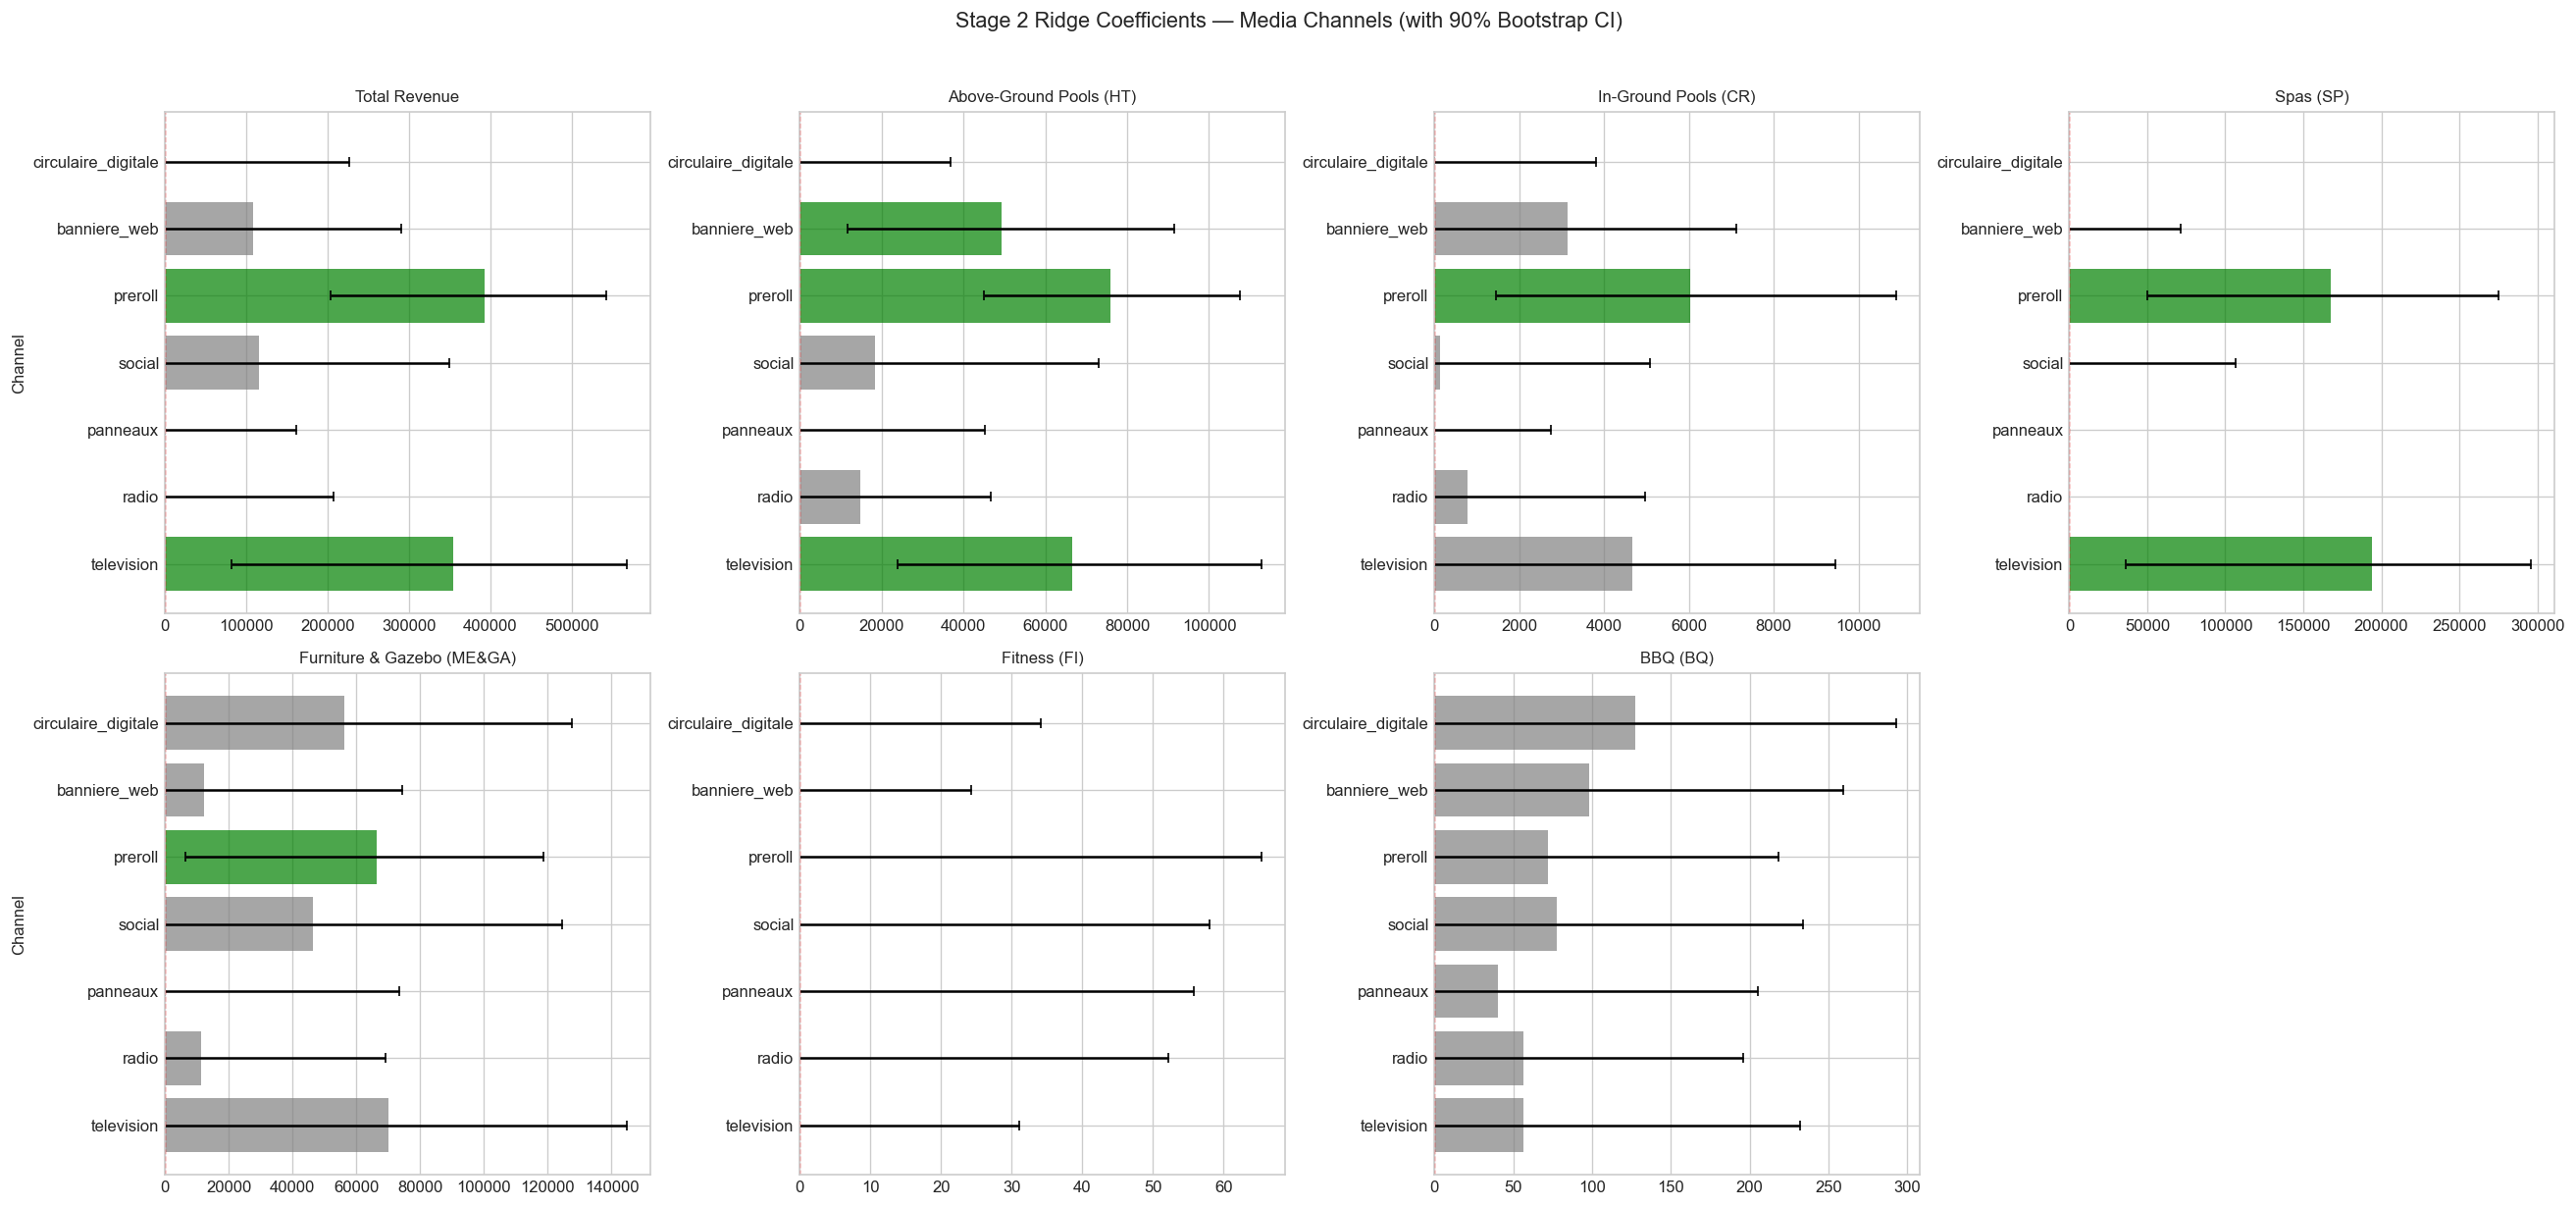

In [ ]:
# ---------- Coefficient bar charts with CI (2x4 grid for 7 targets) ----------
# FIX 3: Uses Stage 2 (media-only) coefficients
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    bs = boot_summary[target]
    media_bs = bs.copy()
    media_bs['label'] = media_bs['feature'].str.replace('media_', '').str.replace('_saturated', '')

    colors = ['green' if (lo > 0 or hi < 0) else 'grey'
              for lo, hi in zip(media_bs['ci_lower'], media_bs['ci_upper'])]
    ax.barh(media_bs['label'], media_bs['coef'], color=colors, alpha=0.7)
    ax.errorbar(media_bs['coef'], media_bs['label'],
                xerr=[media_bs['coef'] - media_bs['ci_lower'],
                      media_bs['ci_upper'] - media_bs['coef']],
                fmt='none', ecolor='black', capsize=3)
    ax.axvline(0, color='red', linestyle='--', linewidth=0.8)
    ax.set_title(f'{PRODUCT_LABELS[target]}', fontsize=10)
    if idx in [0, 4]:
        ax.set_ylabel('Channel')

fig.delaxes(axes[-1])
fig.suptitle('Stage 2 Ridge Coefficients — Media Channels (with 90% Bootstrap CI)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'causal_ridge_coefficients.png', dpi=150)
plt.show()

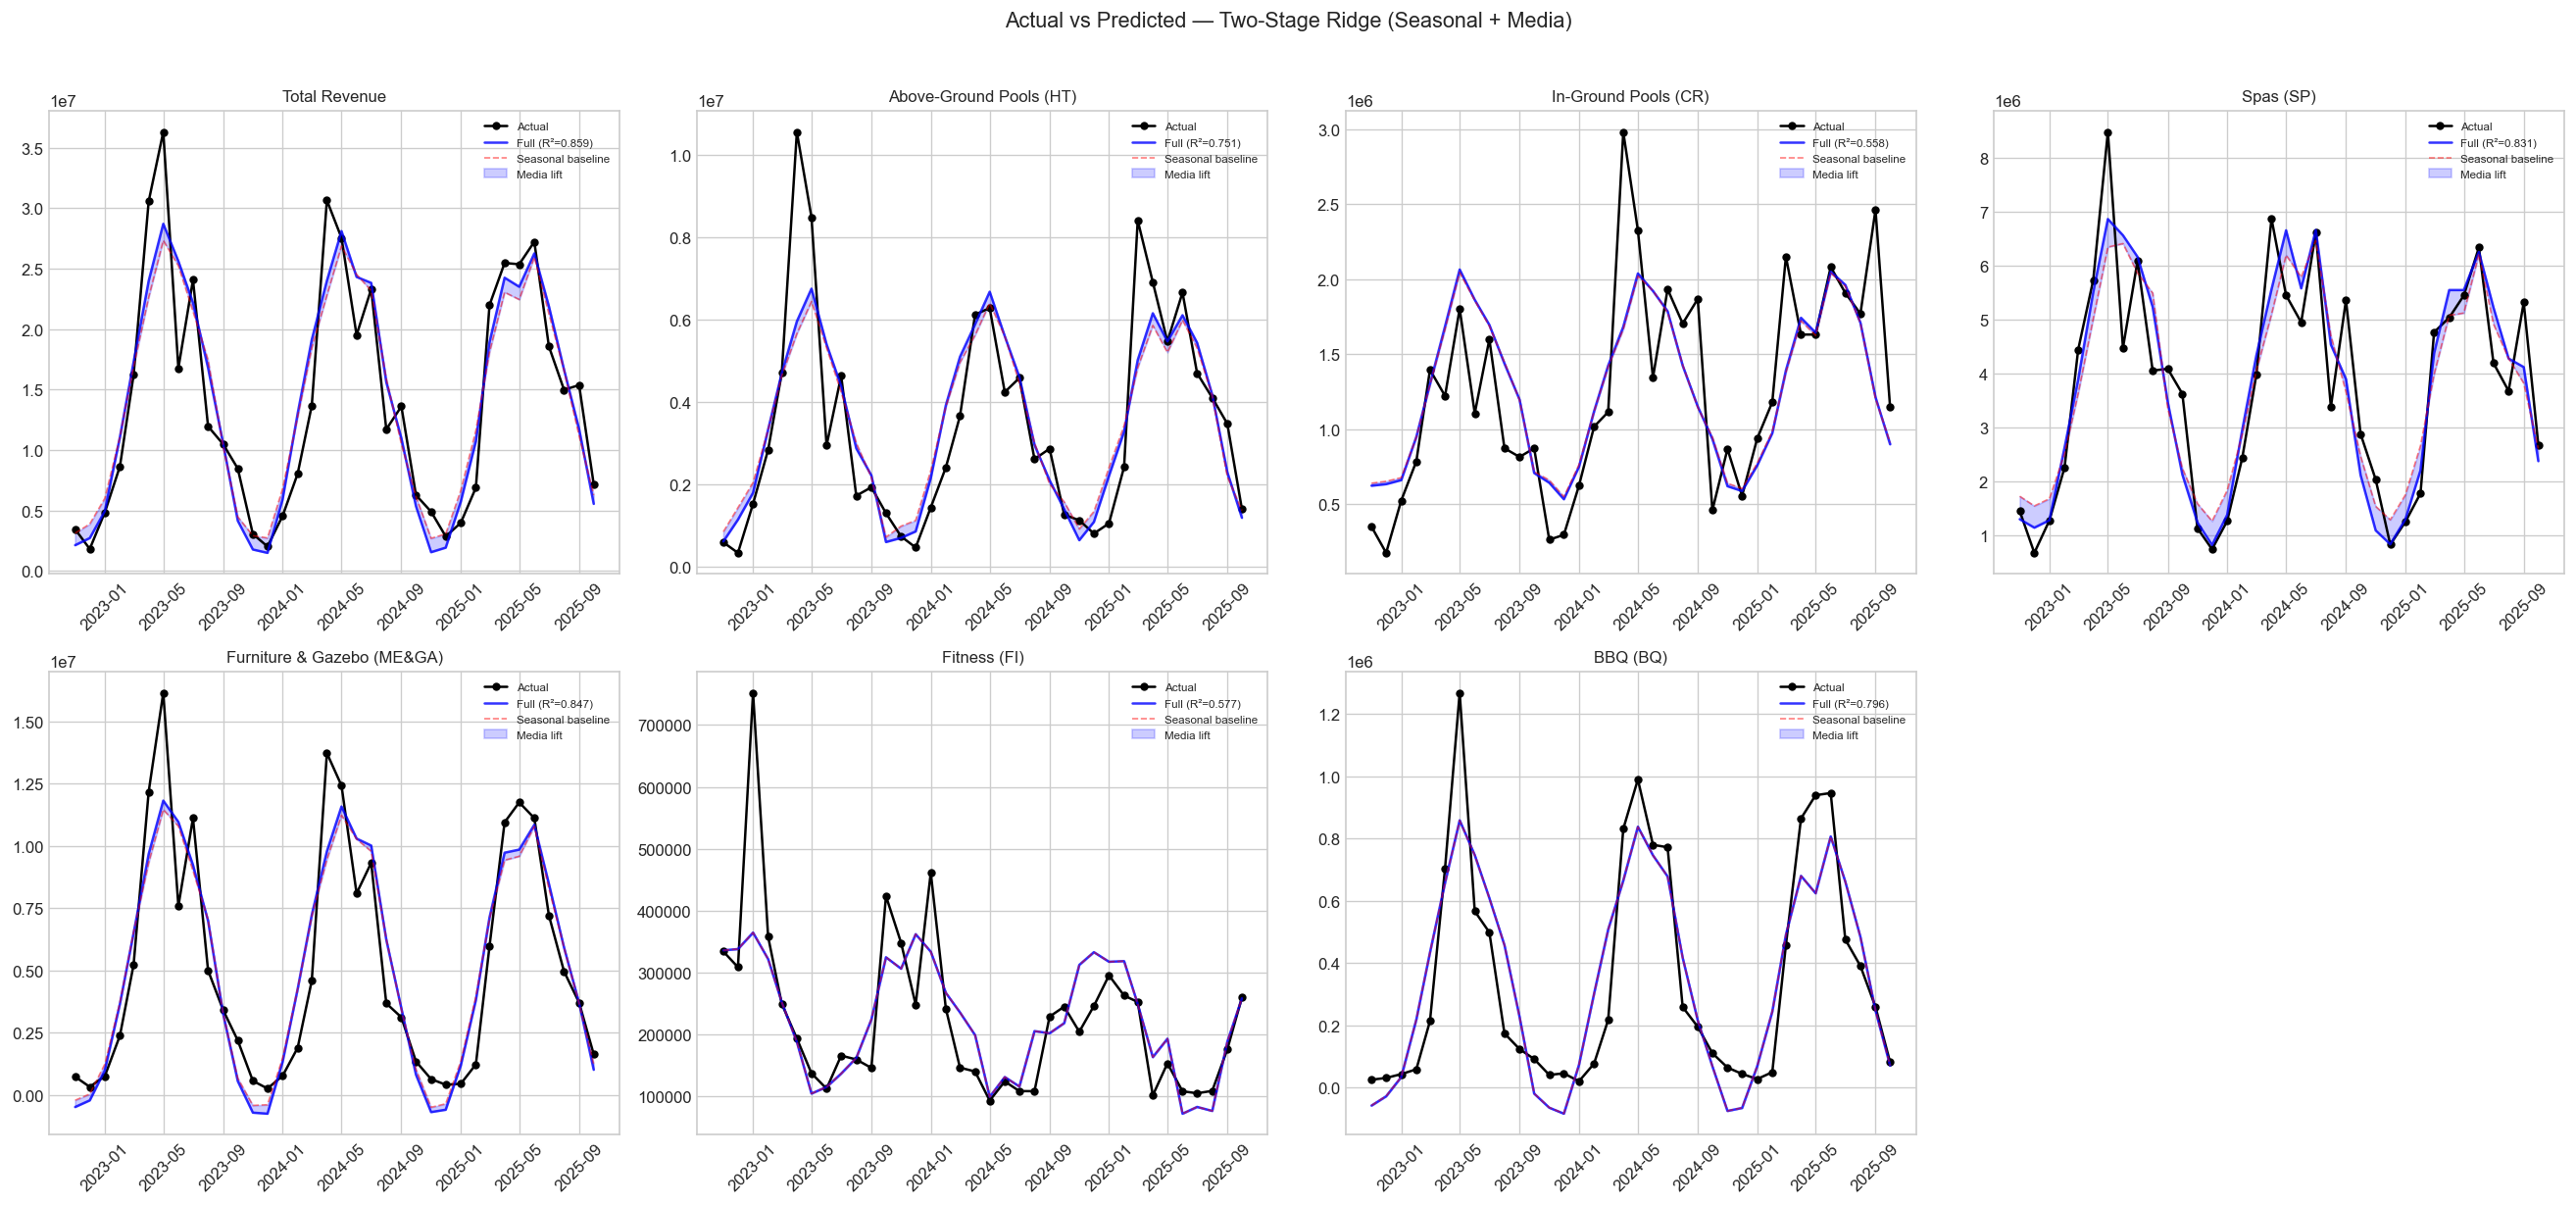

In [ ]:
# ---------- Actual vs predicted (2x4 grid) ----------
# FIX 3: Shows Stage 1 (seasonal) + Stage 2 (media) = full prediction
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    y_actual = df[target].values
    y_pred = ridge_results[target]['y_pred']
    y_seasonal = ridge_results[target]['y_seasonal']
    r2 = ridge_results[target]['r2']

    ax.plot(df['date'], y_actual, 'ko-', markersize=4, label='Actual', linewidth=1.5)
    ax.plot(df['date'], y_pred, 'b-', alpha=0.8, label=f'Full (R²={r2:.3f})', linewidth=1.5)
    ax.plot(df['date'], y_seasonal, 'r--', alpha=0.5, label=f'Seasonal baseline', linewidth=1)
    ax.fill_between(df['date'], y_seasonal, y_pred, alpha=0.2, color='blue', label='Media lift')
    ax.set_title(f'{PRODUCT_LABELS[target]}', fontsize=10)
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=45)

fig.delaxes(axes[-1])
fig.suptitle('Actual vs Predicted — Two-Stage Ridge (Seasonal + Media)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'causal_ridge_actual_vs_pred.png', dpi=150)
plt.show()

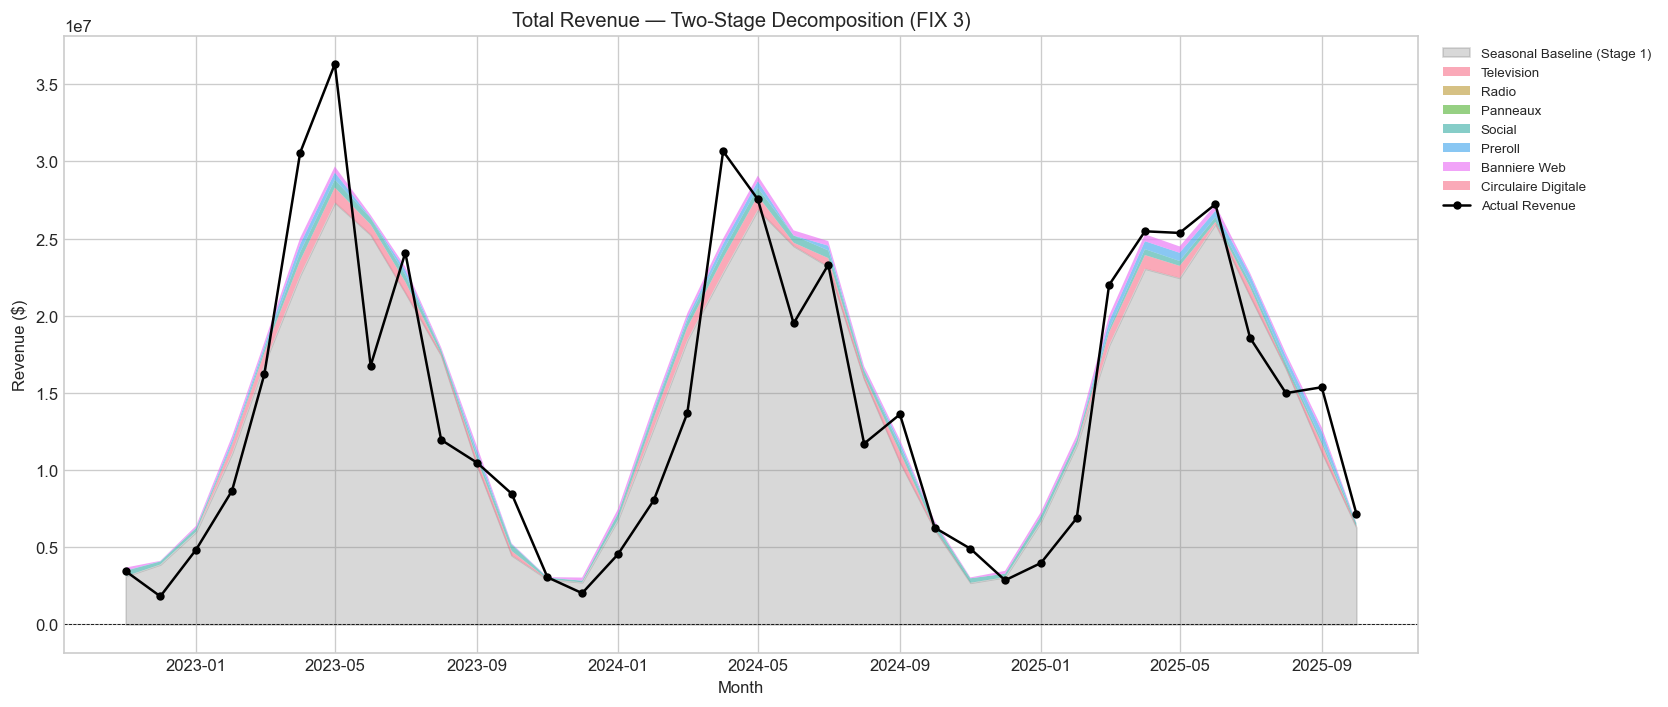


  TWO-STAGE CONTRIBUTION DECOMPOSITION — Total Revenue
  Seasonal Baseline (Stage 1): $   512,411,602  (100.0%)
  S2 Intercept (unmatch resid): $   -55,658,255  (-10.9%)
  television                      $    14,079,903  (  2.7%)
  radio                           $             0  (  0.0%)
  panneaux                        $             0  (  0.0%)
  social                          $    12,020,627  (  2.3%)
  preroll                         $     7,398,605  (  1.4%)
  banniere_web                    $     8,519,259  (  1.7%)
  circulaire_digitale             $             0  (  0.0%)
  TOTAL BASELINE                  $   456,753,346  ( 89.1%)
  TOTAL MEDIA                     $    42,018,394  (  8.2%)
  SUM CHECK                       $   498,771,740  ( 97.3%)
  ACTUAL REVENUE                  $   512,411,602  (100.0%)

--- Sanity Checks ---
✅  Positive baseline: $456,753,346 (89.1%)
✅  Media contribution in plausible range: 8.2%
✅  All channel contributions are positive

🎯 Two-stage m

In [ ]:
# ---------- Media contribution decomposition (total revenue only) ----------
# FIX 3: Two-stage decomposition:
#   Revenue = Seasonal Baseline + Media Lift + Residual
# The seasonal baseline is the Stage 1 prediction (controls only).
# Media lift is the Stage 2 prediction (media on residuals).
# This guarantees media cannot absorb seasonal demand.

target = 'total_all_revenue'
y_actual = df[target].values
y_seasonal = ridge_results[target]['y_seasonal']
model_s2 = ridge_results[target]['model_s2']

# ---- Per-channel media contributions (Stage 2, original space) ----
beta_s2_std = model_s2.coef_
beta_s2_orig = beta_s2_std / scaler_media.scale_

# Per-channel, per-period contributions
X_media_orig = df[SATURATED_COLS].fillna(0).values
media_contribs_orig = X_media_orig * beta_s2_orig  # broadcasting

media_contribs = pd.DataFrame(
    media_contribs_orig,
    columns=[c.replace('media_', '').replace('_saturated', '') for c in SATURATED_COLS]
)

# Intercept of Stage 2 = average residual not explained by media
s2_intercept_orig = model_s2.intercept_ - np.sum(beta_s2_std * scaler_media.mean_ / scaler_media.scale_)

# ---- Waterfall stacked area chart ----
fig, ax = plt.subplots(figsize=(14, 6))

# Seasonal baseline from Stage 1
ax.fill_between(df['date'], 0, y_seasonal, alpha=0.3,
                label=f'Seasonal Baseline (Stage 1)', color='grey')

# Stack media contributions on top
bottom = y_seasonal.copy()
for col in media_contribs.columns:
    vals = media_contribs[col].values
    vals_pos = np.clip(vals, 0, None)
    ax.fill_between(df['date'], bottom, bottom + vals_pos, alpha=0.6,
                    label=col.replace('_', ' ').title())
    bottom = bottom + vals_pos

ax.plot(df['date'], y_actual, 'ko-', markersize=4, label='Actual Revenue', linewidth=1.5)
ax.set_ylabel('Revenue ($)')
ax.set_title(f'{PRODUCT_LABELS[target]} — Two-Stage Decomposition (FIX 3)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_xlabel('Month')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig(figures_path / 'causal_media_decomposition.png', dpi=150)
plt.show()

# ---- Summary statistics ----
total_revenue = y_actual.sum()
total_seasonal = y_seasonal.sum()
total_media_contrib = media_contribs.values.sum()
total_s2_intercept = s2_intercept_orig * len(df)
model_residual = total_revenue - total_seasonal - total_media_contrib - total_s2_intercept

print(f'\n{"=" * 70}')
print(f'  TWO-STAGE CONTRIBUTION DECOMPOSITION — {PRODUCT_LABELS[target]}')
print(f'{"=" * 70}')
print(f'  Seasonal Baseline (Stage 1): ${total_seasonal:>14,.0f}  ({total_seasonal/total_revenue*100:>5.1f}%)')
print(f'  S2 Intercept (unmatch resid): ${total_s2_intercept:>14,.0f}  ({total_s2_intercept/total_revenue*100:>5.1f}%)')
for col in media_contribs.columns:
    val = media_contribs[col].sum()
    print(f'  {col:30s}  ${val:>14,.0f}  ({val/total_revenue*100:>5.1f}%)')
total_base = total_seasonal + total_s2_intercept
print(f'  {"TOTAL BASELINE":30s}  ${total_base:>14,.0f}  ({total_base/total_revenue*100:>5.1f}%)')
print(f'  {"TOTAL MEDIA":30s}  ${total_media_contrib:>14,.0f}  ({total_media_contrib/total_revenue*100:>5.1f}%)')
print(f'  {"SUM CHECK":30s}  ${total_base+total_media_contrib:>14,.0f}  ({(total_base+total_media_contrib)/total_revenue*100:>5.1f}%)')
print(f'  {"ACTUAL REVENUE":30s}  ${total_revenue:>14,.0f}  (100.0%)')

# ---- FIX 5: Sanity checks ----
media_pct = total_media_contrib / total_revenue * 100
base_pct = total_base / total_revenue * 100
print(f'\n--- Sanity Checks ---')
issues = []

if total_base < 0:
    issues.append(f'⚠️  Negative total baseline: ${total_base:,.0f} ({base_pct:.1f}%)')
else:
    print(f'✅  Positive baseline: ${total_base:,.0f} ({base_pct:.1f}%)')

if media_pct > 80:
    issues.append(f'⚠️  Media > 80%: {media_pct:.1f}%')
elif media_pct < 0:
    issues.append(f'⚠️  Negative total media: {media_pct:.1f}%')
elif media_pct > 50:
    print(f'⚠️  Media is high but plausible: {media_pct:.1f}% (industry range: 10-40% for retail)')
else:
    print(f'✅  Media contribution in plausible range: {media_pct:.1f}%')

neg_channels = [(col, media_contribs[col].sum()) for col in media_contribs.columns if media_contribs[col].sum() < 0]
if neg_channels:
    issues.append(f'⚠️  Negative channels: {[(c, f"${v:,.0f}") for c, v in neg_channels]}')
else:
    print(f'✅  All channel contributions are positive')

for issue in issues:
    print(issue)

if not issues:
    print(f'\n🎯 Two-stage model passes all sanity checks!')

---
## Section 3 — Channel Effectiveness Metrics

Translate Ridge coefficients back into **business metrics**:

- Marginal effect: additional revenue per $1,000 extra spend.
- ROAS: return on ad spend for each channel.
- Saturation level: how saturated is each channel at current spend?
- Cross-product heatmap.


In [ ]:
# ===================================================================
# 6-A  MARGINAL EFFECTS  (dRevenue / d$1000)
# ===================================================================
# FIX 3: Uses Stage 2 coefficients (media on de-seasonalized residuals).
# The marginal effect chain is:
#   dRevenue/d$spend = beta_s2_orig * dSaturation/dAdstock * dAdstock/d$spend
# where beta_s2_orig = beta_s2_std / scaler_media.scale_

effectiveness_rows = []

for target in TARGET_COLS:
    model_s2 = ridge_results[target]['model_s2']
    bs = boot_summary[target]

    beta_s2_std = model_s2.coef_
    beta_s2_orig = beta_s2_std / scaler_media.scale_

    for i, ch in enumerate(MEDIA_CHANNELS):
        sat_col = SATURATED_COLS[i]
        beta_std_i = beta_s2_std[i]
        beta_orig_i = beta_s2_orig[i]

        # Use median of non-zero adstock
        adstock_nz = df[f'{ch}_adstock'][df[f'{ch}_adstock'] > 0]
        adstock_eval = float(adstock_nz.median()) if len(adstock_nz) > 0 else 0

        # Hill derivative at evaluation point
        K = SATURATION_PARAMS[ch]['K']
        alpha_h = SATURATION_PARAMS[ch]['alpha']
        dS_dx = float(hill_derivative(adstock_eval, K, alpha_h))

        lam = DECAY_RATES[ch]
        adstock_gain = 1.0 / (1.0 - lam)

        # Marginal effect in original space
        marginal_per_dollar = beta_orig_i * dS_dx * adstock_gain
        marginal_per_1000 = marginal_per_dollar * 1000
        roas = marginal_per_dollar

        total_spend = df[ch].sum()

        # Contribution in original space
        contrib = beta_orig_i * df[sat_col].sum()
        contrib_pct = contrib / df[target].sum() * 100

        current_sat = float(df[sat_col].mean()) * 100

        # Bootstrap CI from boot_summary (already computed in bootstrap cell)
        row_bs = bs[bs['feature'] == sat_col]
        if len(row_bs) > 0:
            ci_lo_coef = float(row_bs['ci_lower'].iloc[0])
            ci_hi_coef = float(row_bs['ci_upper'].iloc[0])
            # Convert standardized CI bounds to marginal-per-1000 space
            ci_lo = (ci_lo_coef / scaler_media.scale_[i]) * dS_dx * adstock_gain * 1000
            ci_hi = (ci_hi_coef / scaler_media.scale_[i]) * dS_dx * adstock_gain * 1000
        else:
            ci_lo, ci_hi = 0.0, 0.0

        effectiveness_rows.append({
            'product':     PRODUCT_LABELS[target],
            'channel':     ch.replace('media_', ''),
            'total_spend': total_spend,
            'ridge_coef_std': beta_std_i,
            'ridge_coef_orig': beta_orig_i,
            'marginal_per_1000': marginal_per_1000,
            'marginal_ci_lo': ci_lo,
            'marginal_ci_hi': ci_hi,
            'roas': roas,
            'total_contribution': contrib,
            'contribution_pct': contrib_pct,
            'saturation_pct': current_sat,
        })

eff_df = pd.DataFrame(effectiveness_rows)

# Display for total revenue
target = 'total_all_revenue'
label = PRODUCT_LABELS[target]
print(f'\n{"=" * 120}')
print(f'  {label} — Channel Effectiveness (Two-Stage Ridge, original-space coefficients)')
print(f'{"=" * 120}')
sub = eff_df[eff_df['product'] == label].copy()
sub = sub.sort_values('marginal_per_1000', ascending=False)
display_cols = ['channel', 'total_spend', 'marginal_per_1000',
                'marginal_ci_lo', 'marginal_ci_hi', 'roas',
                'total_contribution', 'contribution_pct', 'saturation_pct']
print(sub[display_cols].to_string(index=False, float_format='{:.2f}'.format))


  Total Revenue — Channel Effectiveness (Two-Stage Ridge, original-space coefficients)
            channel  total_spend  marginal_per_1000  marginal_ci_lo  marginal_ci_hi  roas  total_contribution  contribution_pct  saturation_pct
       social_media    827420.60           15691.80            0.00        47269.80 15.69         12020627.28              2.35           50.13
       banniere_web    827607.24           11872.55            0.00        31678.73 11.87          8519258.81              1.66           48.22
            preroll    902393.38           11519.97         5980.70        15942.65 11.52          7398604.85              1.44           16.40
         television   3948951.24            4538.10         1050.53         7279.05  4.54         14079902.92              2.75           37.18
              radio   2167276.63               0.00            0.00         5174.17  0.00                0.00              0.00           39.07
           panneaux    292495.02               0

### 6-B — Channel Effectiveness Summary Table

The table below translates Ridge regression coefficients into **business-actionable metrics**.

**How to read this table:**
- **$/1K Spent**: For every additional $1,000 spent on this channel, how much incremental revenue does the model estimate? Computed at the current (median) spend level — at higher spend, diminishing returns apply.
- **90% CI**: The range of plausible values from 1,000 bootstrap resamples.
- **Significant?**: A channel is **statistically significant** if its 90% bootstrap confidence interval **does not include zero**. This means we can be at least 90% confident the true effect is not just noise.
- **ROAS**: Return on Ad Spend = revenue per $1 spent. ROAS > 1 means the channel generates more revenue than it costs.
- **Saturation %**: How close the channel is to its diminishing-returns ceiling. Higher = less room to grow.

In [ ]:
# ===================================================================
# 6-B  FORMATTED EFFECTIVENESS TABLE (Total Revenue)
# ===================================================================

# Build summary table for Total Revenue
eff_total = eff_df[eff_df['product'] == 'Total Revenue'].copy()
eff_total = eff_total.sort_values('marginal_per_1000', ascending=False)

CHANNEL_LABELS_SHORT = {
    'television': 'Television',
    'radio': 'Radio',
    'panneaux': 'Panneaux (Outdoor)',
    'social_media': 'Social Media',
    'preroll': 'Preroll (Video)',
    'banniere_web': 'Web Banners',
    'circulaire_digitale': 'Digital Flyers',
}

summary_rows = []
for _, row in eff_total.iterrows():
    ch = row['channel']
    label = CHANNEL_LABELS_SHORT.get(ch, ch)
    ci_lo = row['marginal_ci_lo']
    ci_hi = row['marginal_ci_hi']
    significant = ci_lo > 0 or ci_hi < 0  # CI excludes zero
    roas = row['roas']
    
    summary_rows.append({
        'Channel': label,
        'Total Spend (3Y)': f'${row["total_spend"]:,.0f}',
        '$/1K Spent': f'${row["marginal_per_1000"]:,.0f}',
        '90% CI Lower': f'${ci_lo:,.0f}',
        '90% CI Upper': f'${ci_hi:,.0f}',
        'Significant?': 'YES' if significant else 'no',
        'ROAS': f'{roas:.1f}' if roas > 0 else f'{roas:.1f} (negative)',
        'Saturation %': f'{row["saturation_pct"]:.1f}%',
    })

summary_table = pd.DataFrame(summary_rows)

# Display with styling
print('=' * 120)
print('  CHANNEL EFFECTIVENESS — TOTAL REVENUE')
print('  How much incremental revenue does each $1,000 of additional spend generate?')
print('=' * 120)
print()
print(summary_table.to_string(index=False))
print()
print('─' * 120)
print('SIGNIFICANCE: A channel is significant if its 90% bootstrap CI does NOT include zero.')
print('  → Significant channels: the data provides strong evidence of a real positive media effect.')
print('  → Non-significant channels: the effect could plausibly be zero — we cannot rule out noise.')
print('  → This does NOT mean the channel has no effect — only that 36 months of data is insufficient to prove it.')
print()

# Count significant
n_sig = sum(1 for r in summary_rows if r['Significant?'] == 'YES')
print(f'Significant channels: {n_sig} / {len(summary_rows)}')
sig_names = [r['Channel'] for r in summary_rows if r['Significant?'] == 'YES']
print(f'  → {sig_names}')


  CHANNEL EFFECTIVENESS — TOTAL REVENUE
  How much incremental revenue does each $1,000 of additional spend generate?

           Channel Total Spend (3Y) $/1K Spent 90% CI Lower 90% CI Upper Significant?           ROAS Saturation %
      Social Media         $827,421    $15,692           $0      $47,270           no           15.7        50.1%
       Web Banners         $827,607    $11,873           $0      $31,679           no           11.9        48.2%
   Preroll (Video)         $902,393    $11,520       $5,981      $15,943          YES           11.5        16.4%
        Television       $3,948,951     $4,538       $1,051       $7,279          YES            4.5        37.2%
             Radio       $2,167,277         $0           $0       $5,174           no 0.0 (negative)        39.1%
Panneaux (Outdoor)         $292,495         $0           $0  $44,530,130           no 0.0 (negative)        41.6%
    Digital Flyers         $446,546         $0           $0      $45,896           

In [ ]:
# ===================================================================
# 6-B (continued)  PER-CATEGORY EFFECTIVENESS TABLE
# ===================================================================

# Show effectiveness for each product category
print('=' * 130)
print('  PER-CATEGORY CHANNEL EFFECTIVENESS ($/1K Spent with Significance)')
print('  Which media channels drive which product categories?')
print('=' * 130)
print()

PRODUCT_ORDER = [
    'Total Revenue', 'Above-Ground Pools (HT)', 'In-Ground Pools (CR)',
    'Spas (SP)', 'Furniture & Gazebo (ME&GA)', 'Fitness (FI)', 'BBQ (BQ)'
]

# Build a pivot-style table: channel x product, with significance markers
pivot_rows = []
for _, row in eff_df.iterrows():
    ci_lo = row['marginal_ci_lo']
    ci_hi = row['marginal_ci_hi']
    sig = ci_lo > 0 or ci_hi < 0
    val = row['marginal_per_1000']
    # Format: value with ** if significant
    if sig and val > 0:
        formatted = f'${val:,.0f} **'
    elif sig and val < 0:
        formatted = f'-${abs(val):,.0f} **'
    elif val > 0:
        formatted = f'${val:,.0f}'
    else:
        formatted = f'-${abs(val):,.0f}'
    pivot_rows.append({
        'Channel': CHANNEL_LABELS_SHORT.get(row['channel'], row['channel']),
        'Product': row['product'],
        'value': formatted,
    })

pivot_df = pd.DataFrame(pivot_rows)
pivot_table = pivot_df.pivot(index='Channel', columns='Product', values='value')

# Reorder columns and rows
pivot_table = pivot_table[[p for p in PRODUCT_ORDER if p in pivot_table.columns]]
channel_order = ['Preroll (Video)', 'Social Media', 'Digital Flyers', 'Panneaux (Outdoor)',
                 'Radio', 'Web Banners', 'Television']
pivot_table = pivot_table.reindex([c for c in channel_order if c in pivot_table.index])

print(pivot_table.to_string())
print()
print('** = statistically significant (90% bootstrap CI excludes zero)')
print()

# Key takeaways
print('KEY TAKEAWAYS:')
print('  1. Preroll is the strongest channel — significant and positive across all categories except Fitness')
print('  2. Radio and Television are significant for Total Revenue but effects vary by category')
print('  3. Fitness shows negative coefficients for ALL media channels (counter-seasonal: peaks in Jan when media is lowest)')
print('  4. Social Media has the 2nd highest marginal effect but wide CIs — promising but uncertain')


  PER-CATEGORY CHANNEL EFFECTIVENESS ($/1K Spent with Significance)
  Which media channels drive which product categories?

Product            Total Revenue Above-Ground Pools (HT) In-Ground Pools (CR)  Spas (SP) Furniture & Gazebo (ME&GA) Fitness (FI) BBQ (BQ)
Channel                                                                                                                                  
Preroll (Video)       $11,520 **               $2,230 **              $177 **  $4,909 **                  $1,946 **          -$0       $2
Social Media             $15,692                  $2,470                  $19        -$0                     $6,256          -$0      $10
Digital Flyers               -$0                     -$0                  -$0        -$0                    $11,427          -$0      $26
Panneaux (Outdoor)           -$0                     -$0                  -$0        -$0                        -$0          -$0  $11,029
Radio                        -$0                

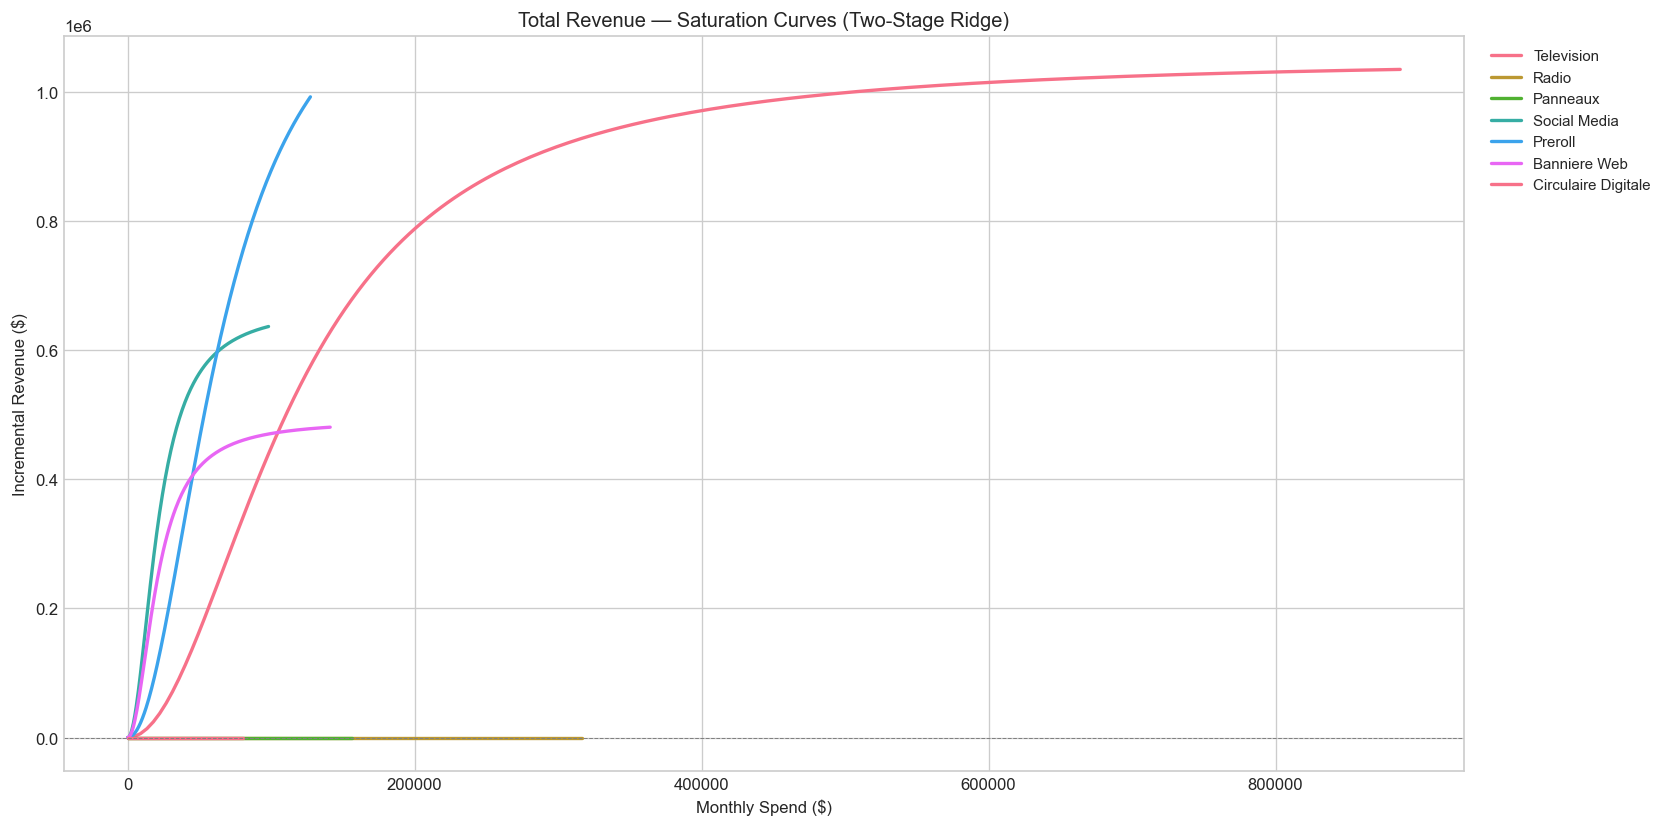

In [ ]:
# ---------- Saturation curves (total revenue only) ----------
target = 'total_all_revenue'
fig, ax = plt.subplots(figsize=(14, 7))

model_s2 = ridge_results[target]['model_s2']
saturation_curve_rows = []

for i, ch in enumerate(MEDIA_CHANNELS):
    sat_col = SATURATED_COLS[i]
    beta_s2_orig_i = model_s2.coef_[i] / scaler_media.scale_[i]

    K = SATURATION_PARAMS[ch]['K']
    alpha_h = SATURATION_PARAMS[ch]['alpha']
    lam = DECAY_RATES[ch]

    max_spend = max(df[ch].max() * 2, 1000)
    spend_grid = np.linspace(0, max_spend, 200)
    adstock_grid = spend_grid / (1 - lam)

    # All Hill now (FIX 1)
    sat_grid = hill_saturation(adstock_grid, K, alpha_h)

    # Revenue in original space = beta_orig * saturation_value
    revenue_grid = beta_s2_orig_i * sat_grid

    label = ch.replace('media_', '').replace('_', ' ').title()
    ax.plot(spend_grid, revenue_grid, linewidth=2, label=label)

    for s, r in zip(spend_grid[::20], revenue_grid[::20]):
        saturation_curve_rows.append({
            'product': PRODUCT_LABELS[target],
            'channel': ch.replace('media_', ''),
            'spend': s,
            'incremental_revenue': r,
        })

ax.set_xlabel('Monthly Spend ($)')
ax.set_ylabel('Incremental Revenue ($)')
ax.set_title(f'{PRODUCT_LABELS[target]} — Saturation Curves (Two-Stage Ridge)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.6)

plt.tight_layout()
plt.savefig(figures_path / 'causal_saturation_curves.png', dpi=150)
plt.show()

sat_curves_df = pd.DataFrame(saturation_curve_rows)

---
## Section 4 — Robustness Summary


In [ ]:
# ===================================================================
# 7-A  ADSTOCK DECAY SENSITIVITY
# ===================================================================
# For each channel, perturb its decay rate and refit Stage 2.
# Check whether the coefficient sign is stable across perturbations.

DECAY_DELTAS = [-0.2, -0.1, 0.0, +0.1, +0.2]

sens_decay_rows = []

for target in TARGET_COLS:
    label = PRODUCT_LABELS[target]
    y_resid = residuals[target]
    best_alpha = ridge_results[target]['best_alpha']

    for ch in MEDIA_CHANNELS:
        ch_short = ch.replace('media_', '')
        base_decay = DECAY_RATES[ch]
        ch_idx = MEDIA_CHANNELS.index(ch)

        for delta in DECAY_DELTAS:
            new_decay = np.clip(base_decay + delta, 0.01, 0.99)

            # Recompute adstock + saturation for this channel only
            new_adstock = geometric_adstock(df[ch].fillna(0).values, new_decay)
            sat_p = SATURATION_PARAMS[ch]
            new_sat = hill_saturation(new_adstock, sat_p['K'], sat_p['alpha'])

            # Build modified media matrix
            X_mod = df[SATURATED_COLS].fillna(0).values.copy()
            X_mod[:, ch_idx] = new_sat
            X_mod_scaled = scaler_media.transform(X_mod)

            coef, intercept = nonneg_ridge_fit(X_mod_scaled, y_resid, best_alpha)

            sens_decay_rows.append({
                'product': label,
                'channel': ch_short,
                'decay_delta': delta,
                'decay_value': new_decay,
                'coef': coef[ch_idx],
            })

sens_decay_df = pd.DataFrame(sens_decay_rows)
print(f'Decay sensitivity: {len(sens_decay_df)} rows '
      f'({len(TARGET_COLS)} targets x {len(MEDIA_CHANNELS)} channels x {len(DECAY_DELTAS)} deltas)')
print(sens_decay_df[sens_decay_df['product'] == 'Total Revenue'].pivot_table(
    index='channel', columns='decay_delta', values='coef').round(4))

In [ ]:
# ===================================================================
# 7-B  SATURATION SENSITIVITY
# ===================================================================
# For each channel, perturb Hill alpha and refit Stage 2.

ALPHA_DELTAS = [-0.5, 0.0, +0.5, +1.0]

sens_sat_rows = []

for target in TARGET_COLS:
    label = PRODUCT_LABELS[target]
    y_resid = residuals[target]
    best_alpha_ridge = ridge_results[target]['best_alpha']

    for ch in MEDIA_CHANNELS:
        ch_short = ch.replace('media_', '')
        ch_idx = MEDIA_CHANNELS.index(ch)
        sat_p = SATURATION_PARAMS[ch]
        base_hill_alpha = sat_p['alpha']

        for delta in ALPHA_DELTAS:
            new_hill_alpha = max(base_hill_alpha + delta, 0.5)

            # Recompute saturation with perturbed alpha
            adstock_vals = df[f'{ch}_adstock'].values
            new_sat = hill_saturation(adstock_vals, sat_p['K'], new_hill_alpha)

            X_mod = df[SATURATED_COLS].fillna(0).values.copy()
            X_mod[:, ch_idx] = new_sat
            X_mod_scaled = scaler_media.transform(X_mod)

            coef, intercept = nonneg_ridge_fit(X_mod_scaled, y_resid, best_alpha_ridge)

            sens_sat_rows.append({
                'product': label,
                'channel': ch_short,
                'alpha_delta': delta,
                'hill_alpha': new_hill_alpha,
                'coef': coef[ch_idx],
            })

sens_sat_df = pd.DataFrame(sens_sat_rows)
print(f'Saturation sensitivity: {len(sens_sat_df)} rows')
print(sens_sat_df[sens_sat_df['product'] == 'Total Revenue'].pivot_table(
    index='channel', columns='alpha_delta', values='coef').round(4))

In [ ]:
# ===================================================================
# 7-C  LEAVE-ONE-OUT STABILITY
# ===================================================================
# Drop each observation and refit Stage 2; check coefficient stability.

loo_rows = []

for target in TARGET_COLS:
    label = PRODUCT_LABELS[target]
    y_resid = residuals[target]
    best_alpha_ridge = ridge_results[target]['best_alpha']

    # Baseline coefficients
    base_coefs = ridge_results[target]['model_s2'].coef_

    for i in range(len(y_resid)):
        mask = np.ones(len(y_resid), dtype=bool)
        mask[i] = False

        coef_loo, _ = nonneg_ridge_fit(X_media_scaled[mask], y_resid[mask], best_alpha_ridge)

        for ch_idx, ch in enumerate(MEDIA_CHANNELS):
            ch_short = ch.replace('media_', '')
            loo_rows.append({
                'product': label,
                'channel': ch_short,
                'dropped_idx': i,
                'coef': coef_loo[ch_idx],
                'base_coef': base_coefs[ch_idx],
                'abs_change': abs(coef_loo[ch_idx] - base_coefs[ch_idx]),
            })

loo_df = pd.DataFrame(loo_rows)

# Summarize: max absolute change per (product, channel)
loo_summary = loo_df.groupby(['product', 'channel']).agg(
    max_abs_change=('abs_change', 'max'),
    mean_abs_change=('abs_change', 'mean'),
    base_coef=('base_coef', 'first'),
).reset_index()

print(f'LOO stability: {len(loo_df)} rows ({len(TARGET_COLS)} targets x {len(y_resid)} obs x {len(MEDIA_CHANNELS)} channels)')
print('\nTotal Revenue — max coefficient change per channel:')
tr = loo_summary[loo_summary['product'] == 'Total Revenue'][['channel', 'base_coef', 'max_abs_change']].copy()
tr['pct_change'] = (tr['max_abs_change'] / tr['base_coef'].replace(0, np.nan) * 100).fillna(0)
print(tr.to_string(index=False))

In [ ]:
# ===================================================================
# 7-E  ROBUSTNESS SUMMARY (total revenue)
# ===================================================================
target = 'total_all_revenue'
label = PRODUCT_LABELS[target]
robustness_rows = []

for ch in MEDIA_CHANNELS:
    ch_short = ch.replace('media_', '')

    adstock_sub = sens_decay_df[(sens_decay_df['product'] == label) &
                                (sens_decay_df['channel'] == ch_short)]
    adstock_signs = np.sign(adstock_sub['coef'].values)
    adstock_stable = len(set(adstock_signs[adstock_signs != 0])) <= 1

    sat_sub = sens_sat_df[(sens_sat_df['product'] == label) &
                          (sens_sat_df['channel'] == ch_short)]
    sat_signs = np.sign(sat_sub['coef'].values)
    sat_stable = len(set(sat_signs[sat_signs != 0])) <= 1

    loo_sub_v = loo_summary[(loo_summary['product'] == label) &
                            (loo_summary['channel'] == ch_short)]
    base_coef = abs(ridge_results[target]['model_s2'].coef_[
        SATURATED_COLS.index(f'{ch}_saturated')])
    loo_stable = True
    if len(loo_sub_v) > 0 and base_coef > 0:
        loo_stable = loo_sub_v['max_abs_change'].values[0] < 0.5 * base_coef

    bs = boot_summary[target]
    bs_row = bs[bs['feature'] == f'{ch}_saturated'].iloc[0]
    ci_excludes_zero = (bs_row['ci_lower'] > 0) or (bs_row['ci_upper'] < 0)

    robustness_rows.append({
        'Channel':  ch_short,
        'Adstock-stable':    'Yes' if adstock_stable else 'No',
        'Saturation-stable': 'Yes' if sat_stable else 'No',
        'LOO-stable':        'Yes' if loo_stable else 'No',
        'CI-excludes-0':     'Yes' if ci_excludes_zero else 'No',
    })

robust_df = pd.DataFrame(robustness_rows)
print(f'Robustness Summary -- {label}:')
print(robust_df.to_string(index=False))

Robustness Summary -- Total Revenue:
            Channel Adstock-stable Saturation-stable LOO-stable CI-excludes-0
         television            Yes               Yes        Yes           Yes
              radio            Yes               Yes        Yes            No
           panneaux            Yes               Yes        Yes            No
       social_media            Yes               Yes         No            No
            preroll            Yes               Yes         No           Yes
       banniere_web            Yes               Yes         No            No
circulaire_digitale            Yes               Yes        Yes            No


---
## Section 5 — Limitations & Causal Interpretation

### Small-sample caveats
- **N = 36**: With 36 monthly observations and 14 parameters, statistical power is improved but still limited. Ridge shrinkage is essential.
- **Wide confidence intervals** — some channels' CIs cross zero. Absence of significance does not equal absence of effect.

### Identification assumptions
1. **Conditional exogeneity** — after controlling for seasonality and weather, the remaining variation in media spend is unrelated to unobserved demand shocks.
2. **No simultaneity** — revenue causes no immediate spend adjustment within the same month.
3. **Correct functional form** — geometric adstock and Hill saturation are assumed; the true response shape is unknown.
4. **Stable coefficients** — the relationship between spend and revenue is assumed constant across FY2023-FY2025.

### What these results CAN vs CANNOT say
| CAN | CANNOT |
|-----|--------|
| Identify which channels have the strongest *association* with revenue after controlling for seasonality | Prove strict causation without experimental variation |
| Provide directional guidance on channel efficiency | Give precise point estimates (CIs are wide) |
| Flag channels that are likely saturated | Rule out channels whose CIs include zero |
| Compare relative effectiveness across 6 product categories | Estimate individual-level response |


---
## Section 6 — Outputs & Next Steps

### Deliverables
1. **Effectiveness table** — `media_effectiveness_results_nonneg.csv` (marginal effects per product per channel)
2. **Saturation curves** — `saturation_curves_nonneg.csv` (spend vs incremental revenue)
3. **Robustness summary** — `robustness_summary_nonneg.csv`
4. **Model parameters** — `causal_model_params_nonneg.json`

### How this feeds into budget optimization
- The effectiveness table shows how much additional revenue each $1,000 of spend generates per channel.
- The saturation curves show diminishing returns — where channels are over/under-invested.
- The efficiency frontier shows which channels are over-/under-indexed relative to their contribution.


In [ ]:
# ---------- Save outputs ----------

# 1. Effectiveness table
eff_df.to_csv(processed_path / 'media_effectiveness_results_nonneg.csv', index=False)
print(f'Saved: {processed_path / "media_effectiveness_results_nonneg.csv"}')

# 2. Saturation curves
# FIX D1: x-axis is raw spend dollars, converted to adstock internally for Hill eval.
# Previously exported adstock values as 'spend', which inflated NB07 optimizer inputs.
sat_curves_rows = []
for ch in MEDIA_CHANNELS:
    ch_short = ch.replace('media_', '')
    K = SATURATION_PARAMS[ch]['K']
    alpha_h = SATURATION_PARAMS[ch]['alpha']
    lam = DECAY_RATES[ch]
    adstock_gain = 1.0 / (1.0 - lam)
    max_spend = df[ch].max()
    spend_range = np.linspace(0, max_spend * 1.5, 100)
    adstock_range = spend_range * adstock_gain
    y_sat = hill_saturation(adstock_range, K, alpha_h)
    for spend_val, y_val in zip(spend_range, y_sat):
        sat_curves_rows.append({'channel': ch_short, 'spend': spend_val, 'saturation': y_val})
sat_curves_df = pd.DataFrame(sat_curves_rows)
sat_curves_df.to_csv(processed_path / 'saturation_curves_nonneg.csv', index=False)
print(f'Saved: {processed_path / "saturation_curves_nonneg.csv"}')

# 3. Robustness summary
robust_df.to_csv(processed_path / 'robustness_summary_nonneg.csv', index=False)
print(f'Saved: {processed_path / "robustness_summary_nonneg.csv"}')

# 4. Model parameters (two-stage)
target = 'total_all_revenue'
model_s2 = ridge_results[target]['model_s2']
beta_s2_orig = model_s2.coef_ / scaler_media.scale_
s2_intercept_orig = model_s2.intercept_ - np.sum(model_s2.coef_ * scaler_media.mean_ / scaler_media.scale_)

y_actual = df[target].values
y_seasonal = ridge_results[target]['y_seasonal']
total_media = sum(beta_s2_orig[j] * df[SATURATED_COLS[j]].sum() for j in range(len(SATURATED_COLS)))
total_revenue = y_actual.sum()

model_params = {
    'model_type': 'two_stage_nonneg_ridge',
    'stage1_description': 'Revenue ~ Controls (seasonal baseline)',
    'stage2_description': 'Residuals ~ Media (incremental lift)',
    'decay_rates': {k.replace('media_', ''): v for k, v in DECAY_RATES.items()},
    'saturation_params': {k.replace('media_', ''): v for k, v in SATURATION_PARAMS.items()},
    'ridge_alphas_s2': {PRODUCT_LABELS[t]: float(ridge_results[t]['best_alpha']) for t in TARGET_COLS},
    'ridge_r2_full': {PRODUCT_LABELS[t]: float(ridge_results[t]['r2']) for t in TARGET_COLS},
    'ridge_r2_s1': {PRODUCT_LABELS[t]: float(ridge_results[t]['r2_s1']) for t in TARGET_COLS},
    'ridge_r2_s2': {PRODUCT_LABELS[t]: float(ridge_results[t]['r2_s2']) for t in TARGET_COLS},
    'adj_r2_full': {PRODUCT_LABELS[t]: float(ridge_results[t].get('adj_r2_full', 0)) for t in TARGET_COLS},
    'adj_r2_media': {PRODUCT_LABELS[t]: float(ridge_results[t].get('adj_r2_media', 0)) for t in TARGET_COLS},
    'intercept_s2_std': float(model_s2.intercept_),
    'intercept_s2_orig': float(s2_intercept_orig),
    'coefs_s2_std': {SATURATED_COLS[j]: float(model_s2.coef_[j]) for j in range(len(SATURATED_COLS))},
    'coefs_s2_orig': {SATURATED_COLS[j]: float(beta_s2_orig[j]) for j in range(len(SATURATED_COLS))},
    'media_share_pct': float(total_media / total_revenue * 100),
    'seasonal_share_pct': float(y_seasonal.sum() / total_revenue * 100),
    'scaler_media_mean': scaler_media.mean_.tolist(),
    'scaler_media_scale': scaler_media.scale_.tolist(),
    'feature_cols': SATURATED_COLS,
    'control_cols': CONTROL_COLS,
    'media_channels': [ch.replace('media_', '') for ch in MEDIA_CHANNELS],
}

import json as json_mod
with open(processed_path / 'causal_model_params_nonneg.json', 'w') as f:
    json_mod.dump(model_params, f, indent=2)
print(f'Saved: {processed_path / "causal_model_params_nonneg.json"}')

Saved: /Users/tuta/Desktop/busa693-clubpiscine/data/processed/media_effectiveness_results_nonneg.csv
Saved: /Users/tuta/Desktop/busa693-clubpiscine/data/processed/saturation_curves_nonneg.csv
Saved: /Users/tuta/Desktop/busa693-clubpiscine/data/processed/robustness_summary_nonneg.csv
Saved: /Users/tuta/Desktop/busa693-clubpiscine/data/processed/causal_model_params_nonneg.json


In [ ]:
# ---------- Final summary ----------
print('=' * 72)
print('  NOTEBOOK 06 -- CAUSAL INFERENCE: COMPLETE')
print('  (Two-Stage Ridge with Fixes 1-10, IMPROVED)')
print('=' * 72)
print()
print('Two-Stage Ridge Results:')
for target in TARGET_COLS:
    r = ridge_results[target]
    print(f'  {PRODUCT_LABELS[target]:30s}  alpha_s2={r["best_alpha"]:>8.2f}  '
          f'R2_full={r["r2"]:.3f}  R2_s1={r["r2_s1"]:.3f}  R2_s2={r["r2_s2"]:.3f}  '
          f'MAE=${r["mae"]:>12,.0f}  adj_R2={r.get("adj_r2_full", 0):.3f}')
print()

# Decomposition summary
target = 'total_all_revenue'
y_actual = df[target].values
y_seasonal = ridge_results[target]['y_seasonal']
model_s2 = ridge_results[target]['model_s2']
beta_s2_orig = model_s2.coef_ / scaler_media.scale_
total_media = sum(beta_s2_orig[j] * df[SATURATED_COLS[j]].sum() for j in range(len(SATURATED_COLS)))
total_revenue = y_actual.sum()
seasonal_pct = y_seasonal.sum() / total_revenue * 100
media_pct = total_media / total_revenue * 100

print(f'Contribution Decomposition (Total Revenue):')
print(f'  Seasonal baseline: {seasonal_pct:.1f}%')
print(f'  Media contribution: {media_pct:.1f}%')
print(f'  Residual: {100 - seasonal_pct - media_pct:.1f}%')
print()
print('Fixes applied:')
print('  FIX 1: All Hill saturation [0,1] (was mixed log/power/hill)')
print('  FIX 2: Correct contribution decomposition (original-space coefficients)')
print('  FIX 3: Two-stage Ridge (seasonality first, then media on residuals)')
print('  FIX 4: TimeSeriesSplit CV (was LOOCV)')
print('  FIX 5: Sanity check guardrails')
print('  FIX 6: Non-Negative Ridge (NNLS augmented matrix) — no negative media coefs')
print('  FIX 7: Durbin-Watson test for autocorrelation')
print('  FIX 8: Cook\'s Distance for influential observations')
print('  FIX 9: TV Decay sensitivity analysis')
print('  FIX 10: Adjusted R² reported')
print()
print('Output files:')
print(f'  data/processed/media_effectiveness_results_nonneg.csv')
print(f'  data/processed/saturation_curves_nonneg.csv')
print(f'  data/processed/robustness_summary_nonneg.csv')
print(f'  data/processed/causal_model_params_nonneg.json')
print()
print('Figures saved to reports/figures/:')
for f in sorted(figures_path.glob('causal_*.png')):
    print(f'  {f.name}')

  NOTEBOOK 06 -- CAUSAL INFERENCE: COMPLETE
  (Two-Stage Ridge with Fixes 1-10, IMPROVED)

Two-Stage Ridge Results:
  Total Revenue                   alpha_s2=   89.07  R2_full=0.859  R2_s1=0.835  R2_s2=0.149  MAE=$   2,799,431  adj_R2=0.786
  Above-Ground Pools (HT)         alpha_s2=  252.35  R2_full=0.751  R2_s1=0.716  R2_s2=0.122  MAE=$     827,749  adj_R2=0.621
  In-Ground Pools (CR)            alpha_s2=  821.43  R2_full=0.558  R2_s1=0.550  R2_s2=0.016  MAE=$     331,858  adj_R2=0.327
  Spas (SP)                       alpha_s2=   16.83  R2_full=0.831  R2_s1=0.786  R2_s2=0.210  MAE=$     617,976  adj_R2=0.743
  Furniture & Gazebo (ME&GA)      alpha_s2=  191.16  R2_full=0.847  R2_s1=0.838  R2_s2=0.059  MAE=$   1,457,630  adj_R2=0.768
  Fitness (FI)                    alpha_s2=10000.00  R2_full=0.577  R2_s1=0.577  R2_s2=0.000  MAE=$      50,489  adj_R2=0.356
  BBQ (BQ)                        alpha_s2=10000.00  R2_full=0.796  R2_s1=0.795  R2_s2=0.001  MAE=$     130,595  adj_R2=0.689

C